In [1]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import sys
import pickle

sys.path.insert(0, "../utils")

from modules import *

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, log_loss, mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from Model_Validation_Module import *

enc = 'utf-8'

In [2]:
df_extnord = pd.read_csv(f'../data/ExtNord/CM_ExtNord_Dataset_2015-2024.csv', encoding=enc)
df_nord = pd.read_csv(f'../data/Nord/CM_Nord_Dataset_2015-2024.csv', encoding=enc)

dataframe = pd.concat([df_extnord, df_nord], ignore_index=True)

In [3]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_recorded_cases', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

dataframe = dataframe[['location'] + dataframe.columns.to_list()[:-1]]

In [4]:
dataframe.drop(columns=['Case_UND5', 'Case_OVR5', 'Case_PRGN', 
                      'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                      'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL',
                      'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL'], inplace=True)

dataframe.rename(columns={'Case_TOTAL': 'cases'}, inplace=True)

In [5]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [6]:
dataframe.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,27.33,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,94
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,27.33,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,7
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,27.50,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,91
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,27.83,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,31
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,28.00,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,109


In [7]:
bin_ranges = [0, 
              1,
              #2,
              #4, 
              8, 
              16, 
              32, 
              64, 
              128, 
              256, 
              512, 
              1024, 
              #2048, 
              #4096, 
              8192]

In [8]:
risk_classes = list(range(0,10))
risk_classes

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [9]:
bins, bounds = pd.cut(x = dataframe.loc[:, 'cases'], bins=bin_ranges, right=False, include_lowest=True, labels=risk_classes, retbins=True, precision=0)

In [10]:
dataframe['case_bin'] = bins

In [11]:
# dataset = pd.concat([data_0, data_rest])

dataset = dataframe.copy()

In [12]:
dataset['case_bin'] = pd.Categorical(dataset['case_bin'])

In [13]:
# bounds = np.concatenate(([0], bounds))
bounds = np.array(bounds, dtype=int)
print(f'Bounds: {bounds}')

Bounds: [   0    1    8   16   32   64  128  256  512 1024 8192]


In [14]:
dataset.sort_values(["dt_prediction", "location"], inplace=True)
dataset.reset_index(drop=True, inplace=True)

[Text(0, 0, '0'),
 Text(1, 0, '[1-8]'),
 Text(2, 0, '(8-16]'),
 Text(3, 0, '(16-32]'),
 Text(4, 0, '(32-64]'),
 Text(5, 0, '(64-128]'),
 Text(6, 0, '(128-256]'),
 Text(7, 0, '(256-512]'),
 Text(8, 0, '(512-1024]'),
 Text(9, 0, '1024+')]

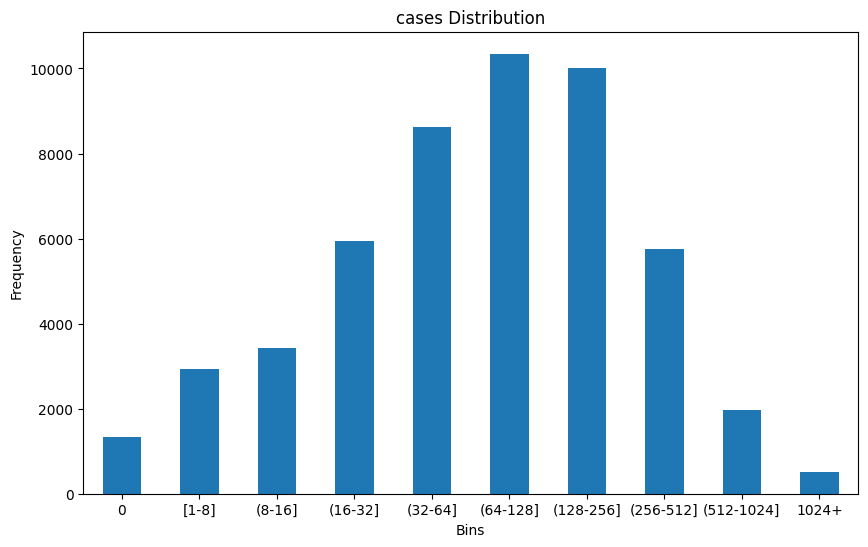

In [15]:
target_col = 'cases'

ax = dataset['case_bin'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10, 6),
    title=f'{target_col} Distribution',
    xlabel='Bins',
    ylabel='Frequency'
)

# Set custom x-axis tick labels
ax.set_xticklabels(['0', '[1-8]', '(8-16]', '(16-32]','(32-64]','(64-128]','(128-256]','(256-512]','(512-1024]','1024+'], rotation=0) 
        

In [16]:
dataset

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases,case_bin
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,1377.0,496.0,0.0,144.44,1114.0,0.0,97.0,914.0,94,5
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,1303.0,489.0,0.0,149.02,1078.0,0.0,66.0,1078.0,7,1
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,1359.0,489.0,0.0,146.88,1124.0,0.0,89.0,891.0,91,5
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,1451.0,512.0,0.0,144.81,1188.0,0.0,92.0,1188.0,31,3
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,1343.0,481.0,0.0,145.68,1106.0,1.0,93.0,911.0,109,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50834,"(nord, mayo-rey, touboro, mbeing)",15.001895,7.650008,2024-09,-1.000,0.0,0.444202,0.246985,-0.353127,-0.246985,...,2746.0,582.0,0.0,91.49,1488.0,0.0,205.0,1488.0,59,4
50835,"(nord, mayo-rey, touboro, ngai-lara)",15.110765,7.963850,2024-09,-1.000,0.0,0.594980,0.262238,-0.460305,-0.262238,...,2791.0,626.0,0.0,97.38,1598.0,0.0,175.0,1598.0,126,5
50836,"(nord, mayo-rey, touboro, touboro)",15.293957,7.759324,2024-09,-1.000,0.0,0.592537,0.214245,-0.454020,-0.214245,...,2842.0,589.0,0.0,94.80,1630.0,2.0,462.0,1630.0,656,8
50837,"(nord, mayo-rey, touboro, vogzom)",14.714359,7.747549,2024-09,-1.000,0.0,0.599925,0.240514,-0.463363,-0.240514,...,2527.0,490.0,0.0,93.43,1316.0,0.0,163.0,1316.0,403,7


In [17]:
X = dataset.select_dtypes(exclude=['object', 'period[M]']).drop(columns=['cases', 'case_bin'])
y = dataset['case_bin']

n_folds = 10
k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [18]:
features_to_remove = []

feature_names = X.drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['x', 'y', 'month_sin', 'month_cos', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_min_prev_month', 'lst_max_prev_month', 'rainfall', 'rainfall_acc_prev_month', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19']
Total Features Used: 66


In [19]:
with open("rfecv_model.pkl", "rb") as f:
    fitted_rfe = pickle.load(f)

In [20]:
model_params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'learning_rate': 0.3,
    'n_estimators': 200, 
    'min_child_weight': 4,
    'gamma': 0,
    'random_state': 0
}

In [21]:
fold_counter = 0
n_models = 10 

y_true_list = []
y_pred_list = []
y_index_list = []

for train_idx, test_idx in k_fold.split(X, y):
    print(f'Fold: {fold_counter+1}/{n_folds}')

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    imputer = KNNImputer(n_neighbors=3)
    imputer.fit(X_train_scaled)
    X_train_imputed = pd.DataFrame(imputer.transform(X_train_scaled), columns=X_train.columns, index=X_train.index)
    X_test_imputed = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test.columns, index=X_test.index)

    X_train_imputed = pd.DataFrame(scaler.inverse_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
    X_test_imputed = pd.DataFrame(scaler.inverse_transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

    X_train_imputed = round_columns(X_train_imputed, round_cols, round_factor)
    X_test_imputed = round_columns(X_test_imputed, round_cols, round_factor)

    X_train_rfe = pd.DataFrame(fitted_rfe.transform(X_train_imputed), columns = X.columns[fitted_rfe.support_], index=X_train.index)
    X_test_rfe = pd.DataFrame(fitted_rfe.transform(X_test_imputed), columns = X.columns[fitted_rfe.support_], index=X_test.index)

    ## --- Ensemble Model Training ---
    y_pred_ensemble_list = []

    for model in range(n_models):
        print(f"\tEnsemble Model {model+1}/{n_models}", end='\r')
        ensemble_params = model_params.copy()
        ensemble_params['subsample'] = 0.8
        ensemble_params['colsample_bytree'] = 0.8
        ensemble_params['seed'] = model * 100 + fold_counter

        model = xgb.XGBRegressor(**ensemble_params)   
        fitted_model = model.fit(X_train_rfe, y_train, verbose=False)

        y_pred = fitted_model.predict(X_test_rfe)

        y_pred_ensemble_list.append(y_pred)

    y_true_list.append(y_test)
    y_pred_list.append(y_pred_ensemble_list)
    y_index_list.append(test_idx)

    fold_counter += 1
    print('\n', end='\r')

Fold: 1/10


	Ensemble Model 10/10
Fold: 2/10
	Ensemble Model 10/10
Fold: 3/10
	Ensemble Model 10/10
Fold: 4/10
	Ensemble Model 10/10
Fold: 5/10
	Ensemble Model 10/10
Fold: 6/10
	Ensemble Model 10/10
Fold: 7/10
	Ensemble Model 10/10
Fold: 8/10
	Ensemble Model 10/10
Fold: 9/10
	Ensemble Model 10/10
Fold: 10/10
	Ensemble Model 10/10


In [22]:
y_true = np.concatenate(y_true_list, axis=0)
y_preds = [np.column_stack(pred) for pred in y_pred_list]
y_pred = np.vstack(y_preds)
# y_pred = np.clip(np.round(y_pred), 0, 9).astype(int)
y_pred = np.clip(y_pred, 0, 9)
y_index = np.concatenate(y_index_list, axis=0)

In [23]:
ens_columns = [f"ens_{i+1}" for i in range(y_pred.shape[1])]

df_ensembles = pd.DataFrame(
    data=y_pred,
    index=y_index,
    columns=ens_columns
)

df_ensembles['y_true'] = y_true
df_ensembles.sort_index(inplace=True)

In [24]:
# Mean prediction (ensemble average)
df_ensembles['y_pred_mean'] = df_ensembles[ens_columns].mean(axis=1)

# Uncertainty (std dev of ensemble predictions)
df_ensembles['y_uncertainty'] = df_ensembles[ens_columns].std(axis=1)

In [25]:
from scipy.stats import norm

z = norm.ppf(0.975)  # ~1.96

df_ensembles['pred_lower'] = df_ensembles['y_pred_mean'] - z * df_ensembles['y_uncertainty']
df_ensembles['pred_upper'] = df_ensembles['y_pred_mean'] + z * df_ensembles['y_uncertainty']

In [26]:
df_ensembles

,ens_1,ens_2,ens_3,ens_4,ens_5,ens_6,ens_7,ens_8,ens_9,ens_10,y_true,y_pred_mean,y_uncertainty,pred_lower,pred_upper
0,5.650303,4.970142,5.405662,4.801901,6.193620,4.972790,5.163036,5.522414,5.205441,5.179969,5,5.306528,0.406552,4.509702,6.103354
1,3.361650,4.084666,3.747380,2.093505,3.258153,3.535940,3.489798,3.683434,3.032194,3.601104,1,3.388782,0.537412,2.335474,4.442090
2,5.293070,4.754250,5.106986,4.892106,5.084615,4.865785,5.350426,4.585114,5.136546,5.498622,5,5.056752,0.283732,4.500648,5.612856
3,2.976165,2.805503,3.322156,4.534667,2.818717,2.178503,3.661186,3.170884,2.899181,2.535051,3,3.090201,0.651192,1.813889,4.366513
4,3.282638,3.863879,3.924370,3.098977,4.094952,4.575264,5.151939,4.424926,3.709211,3.921881,5,4.004804,0.604483,2.820038,5.189569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50834,5.198372,4.997377,4.802947,4.669951,5.054536,4.718821,4.875201,5.269964,4.472024,4.748743,4,4.880794,0.248864,4.393030,5.368557
50835,5.967970,6.571140,6.235358,6.203682,5.955777,7.007729,5.790772,5.979081,5.792958,5.779136,5,6.128360,0.396187,5.351848,6.904872
50836,6.860925,7.556814,7.177344,7.759445,7.032404,7.710052,7.614290,7.839546,7.788590,7.565296,8,7.490470,0.343321,6.817573,8.163366
50837,6.788549,6.919692,6.590093,7.200453,6.766009,7.052347,6.595461,7.555989,6.499704,7.031122,7,6.899942,0.323313,6.266260,7.533624


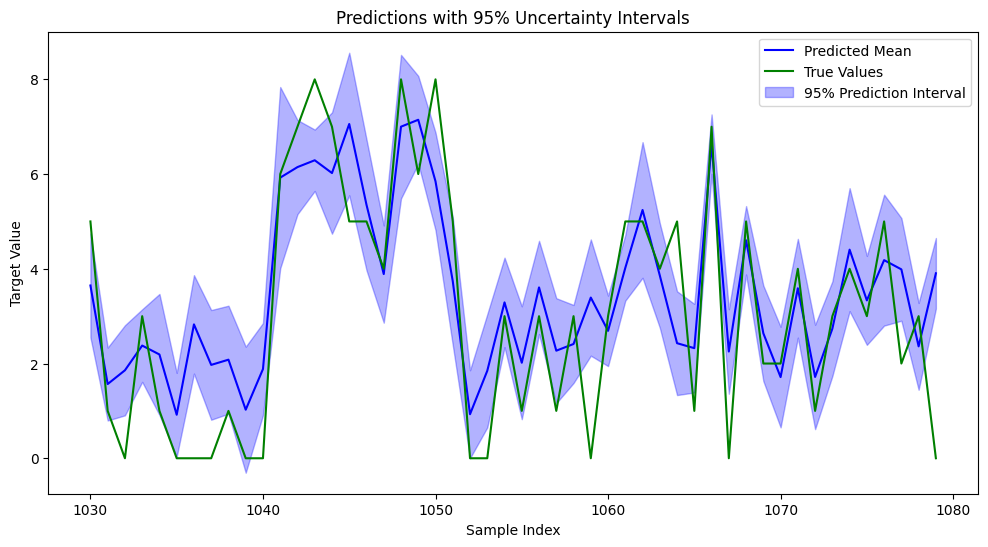

In [27]:
import matplotlib.pyplot as plt

# Select a subset (e.g., first 100 samples) to keep plot clear
subset = df_ensembles.iloc[1030:1080]

plt.figure(figsize=(12,6))

# Plot mean prediction
plt.plot(subset.index, subset["y_pred_mean"], label="Predicted Mean", color="blue")

# Plot ground truth
plt.plot(subset.index, subset["y_true"], label="True Values", color="green")

# Fill between prediction intervals
plt.fill_between(
    subset.index,
    subset["pred_lower"],
    subset["pred_upper"],
    color="blue",
    alpha=0.3,
    label="95% Prediction Interval"
)

plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.title("Predictions with 95% Uncertainty Intervals")
plt.legend()
plt.show()

In [28]:
df_ensembles_sorted = df_ensembles.sort_values(by='y_pred_mean').reset_index(drop=True)

In [29]:
df_ensembles_sorted.head()

,ens_1,ens_2,ens_3,ens_4,ens_5,ens_6,ens_7,ens_8,ens_9,ens_10,y_true,y_pred_mean,y_uncertainty,pred_lower,pred_upper
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0


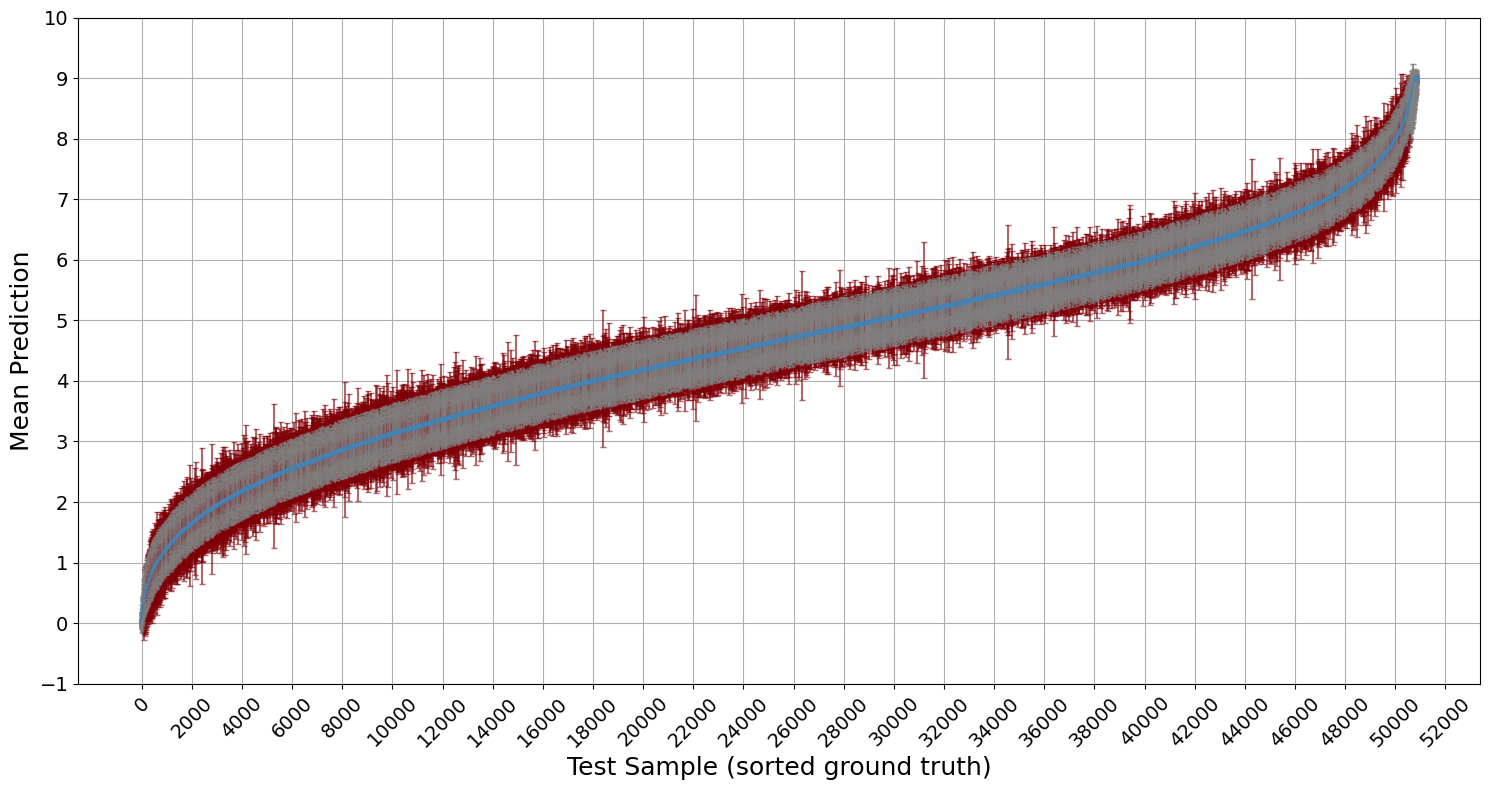

In [30]:
label_size = 18 
tick_size = 14
x_ticks_max = df_ensembles_sorted.shape[0]

plt.figure(figsize=(15, 8))

# Loop through each sample
for i in range(len(df_ensembles_sorted)):
    mean = df_ensembles_sorted['y_pred_mean'].iloc[i]
    std = df_ensembles_sorted['y_uncertainty'].iloc[i]
    
    err_color = '#7f0007' if std > 0.5 else 'gray'

    # Plot error bar only (no marker)
    plt.errorbar(
        x=i,
        y=mean,
        yerr=std,
        fmt='none',          # No marker
        ecolor=err_color,
        alpha=0.4 if err_color == 'grey' else 0.6,           # Alpha for error bars
        capsize=2
    )

    # Plot marker separately
    plt.plot(
        i,
        mean,
        'o',
        markersize=3,
        color='steelblue',       # Marker color
        alpha=1           # Alpha for marker
    )

plt.xlabel("Test Sample (sorted ground truth)", size=label_size)
plt.ylabel("Mean Prediction", size=label_size)
plt.yticks(np.arange(-1, 11, step=1), size=tick_size)
plt.xticks(np.arange(0, round(x_ticks_max * 1.05, -2), step=2000), size=tick_size)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [31]:
num_high_uncertainty = df_ensembles[df_ensembles['y_uncertainty'] >= 0.5].shape[0]
total_samples = df_ensembles.shape[0]
percentage_high_uncertainty = (num_high_uncertainty / total_samples) * 100
percentage_high_uncertainty

7.52178445681465

In [32]:
print(f"Average Uncertainty of Predictions: {df_ensembles['y_uncertainty'].mean():.4f}")
print(f"High-risk Uncertainty of Predictions: {df_ensembles[df_ensembles['y_pred_mean'] >= 5]['y_uncertainty'].mean():.4f}")
print(f"Low-risk Uncertainty of Predictions: {df_ensembles[df_ensembles['y_pred_mean'] < 5]['y_uncertainty'].mean():.4f}")

Average Uncertainty of Predictions: 0.3229
High-risk Uncertainty of Predictions: 0.3027
Low-risk Uncertainty of Predictions: 0.3377


In [33]:
print(f"Average Std Dev of Predictions: {df_ensembles['y_uncertainty'].mean():.4f}")

print(f"Top 5 Most Uncertain Samples by Std Dev:\n{df_ensembles.sort_values(by='y_uncertainty', ascending=False).head()}")

Average Std Dev of Predictions: 0.3229
Top 5 Most Uncertain Samples by Std Dev:
          ens_1     ens_2     ens_3     ens_4     ens_5     ens_6     ens_7  \
10213  3.047456  4.149855  1.842207  0.000000  1.238274  2.495498  3.306358   
8277   8.141436  6.313025  5.213528  7.575775  6.445639  7.060190  6.247970   
40975  3.486101  5.361962  3.904224  6.246227  2.798320  3.894408  2.797755   
9046   4.010911  3.952127  7.057415  3.790149  5.187420  5.231199  5.599422   
46370  1.298335  2.346749  1.131565  1.767617  2.546972  2.912234  1.128828   

          ens_8     ens_9    ens_10  y_true  y_pred_mean  y_uncertainty  \
10213  2.249566  3.410403  2.555725       4     2.429534       1.192179   
8277   7.323909  6.588893  4.192149       8     6.510252       1.151507   
40975  3.574974  3.341565  4.950119       5     4.035565       1.134244   
9046   5.101136  4.904953  6.821422       6     5.165616       1.119696   
46370  0.472109  0.304499  3.805462       2     1.771437       1.11840